In [55]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

print("X:", X)
print("y:", y)

X: [50. 60. 70. 80. 90.]
y: [150. 180. 210. 240. 270.]


In [56]:
# Define the LinearRegressionGD class
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.alpha = learning_rate
        self.n_iters = n_iters
        self.theta_1 = 0.0   # w (slope)
        self.theta_0 = 0.0   # b (intercept)
        self.sse_history = []

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        n = len(X)

        self.theta_1 = 0.0
        self.theta_0 = 0.0
        self.sse_history = []

        for i in range(self.n_iters):
            y_hat = self.theta_1 * X + self.theta_0

            D_w = (2 / n) * np.sum((y_hat - y) * X)
            D_b = (2 / n) * np.sum(y_hat - y)

            self.theta_1 -= self.alpha * D_w
            self.theta_0 -= self.alpha * D_b

            sse = np.sum((y_hat - y) ** 2)
            self.sse_history.append(sse)

        return self

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.theta_1 * X + self.theta_0

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y_pred - np.array(y, dtype=float)) ** 2)

    def plot_training(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(range(self.n_iters), self.sse_history, label="sse")
        plt.xlabel("Iteration")
        plt.ylabel("SSE")
        plt.title("SSE over iteration")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.scatter(X, y, color="blue", label="Data Points")
        plt.plot(X, self.theta_0 + self.theta_1 * X, color="red", label="Regression Line")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Linear Regression Fit line")
        plt.legend()
        plt.show()

In [57]:
# Create and train the model
model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
model.fit(X, y)

print("theta_0 =", model.theta_0)
print("theta_1 =", model.theta_1)

theta_0 = 0.04113676040970018
theta_1 = 2.999435373457505


In [58]:
# Predict the price
X_new = 70
predicted_price = model.predict([X_new])[0]
print(f"Predicted price for {X_new} m²: {predicted_price:.2f} (thousands)")

Predicted price for 70 m²: 210.00 (thousands)


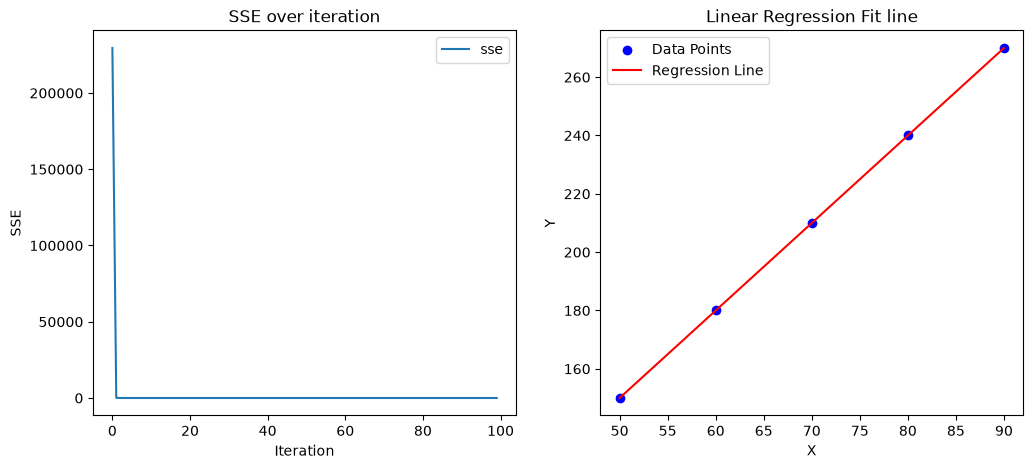

In [59]:
# Predict the price
model.plot_training(X, y)

In [60]:
# Experiment with different learning rates
learning_rates = {
    "very small (alpha=0.00001)": 0.00001,
    "small (alpha=0.0001)": 0.0001,
    "large (alpha=0.001)": 0.001,
}

results = {}
for label, alpha in learning_rates.items():
    m = LinearRegressionGD(learning_rate=alpha, n_iters=100)
    m.fit(X, y)
    results[label] = m
    print(f"{label:30s} -> theta_0={m.theta_0:.4f}, theta_1={m.theta_1:.4f}, final SSE={m.sse_history[-1]:.6g}")

very small (alpha=0.00001)     -> theta_0=0.0412, theta_1=2.9994, final SSE=0.000460412
small (alpha=0.0001)           -> theta_0=0.0411, theta_1=2.9994, final SSE=0.000331816
large (alpha=0.001)            -> theta_0=-100559579014623924767868844963106037062468117326748939450646927531409404026744153322495982698496.0000, theta_1=-7326427288635143620967053747859690313234556035638624697732592825340190692364436098326902412935168.0000, final SSE=1.61708e+196


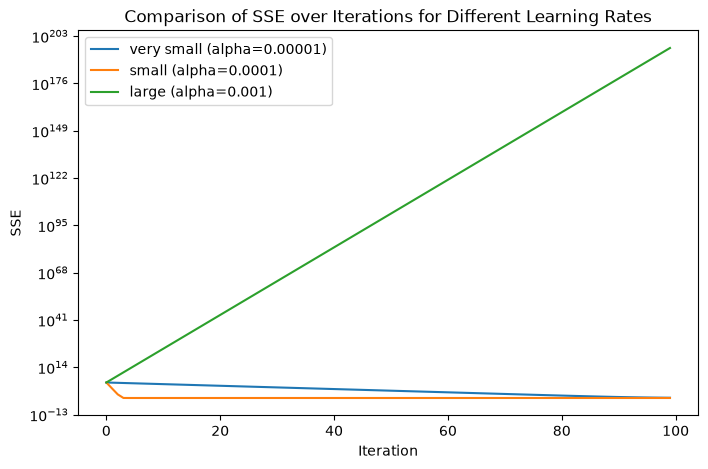

In [61]:
# Plot SSE comparison across the different learning rates
plt.figure(figsize=(8, 5))
for label, m in results.items():
    plt.plot(m.sse_history, label=label)

plt.title("Comparison of SSE over Iterations for Different Learning Rates")
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.yscale("log")
plt.legend()
plt.show()

In [62]:
# Compute MSE for the model
print("MSE:", model.mse(X, y))

MSE: 6.636208076299688e-05


Without normalization -> final SSE: 0.00033181560776546876
With normalization    -> final SSE: 0.00019989390808120938


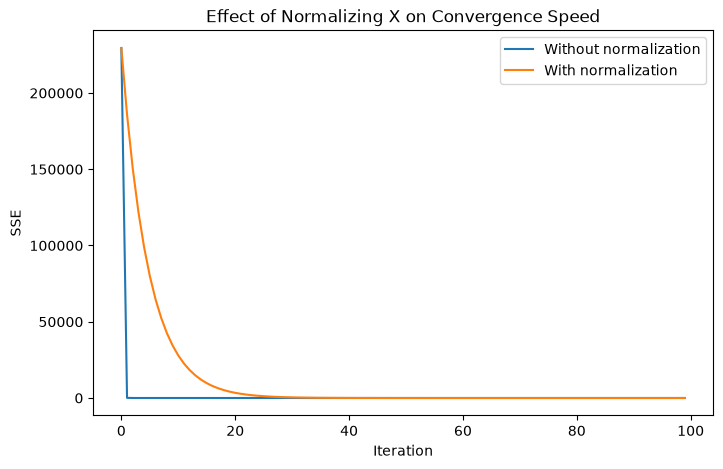

In [63]:
# Normalize X before training and compare results

# Z-score normalization
X_mean = X.mean()
X_std = X.std()
X_norm = (X - X_mean) / X_std

model_norm = LinearRegressionGD(learning_rate=0.05, n_iters=100)
model_norm.fit(X_norm, y)

print("Without normalization -> final SSE:", model.sse_history[-1])
print("With normalization    -> final SSE:", model_norm.sse_history[-1])

plt.figure(figsize=(8, 5))
plt.plot(model.sse_history, label="Without normalization")
plt.plot(model_norm.sse_history, label="With normalization")
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.title("Effect of Normalizing X on Convergence Speed")
plt.legend()
plt.show()

In [64]:
# Modify the class to support multiple features

class LinearRegressionGD_Multi:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.alpha = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.thetas = None
        self.sse_history = []

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        n_samples, n_features = X.shape

        self.theta_0 = 0.0
        self.thetas = np.zeros(n_features)
        self.sse_history = []

        for i in range(self.n_iters):
            y_hat = X @ self.thetas + self.theta_0

            D_thetas = (2 / n_samples) * (X.T @ (y_hat - y))
            D_theta0 = (2 / n_samples) * np.sum(y_hat - y)

            self.thetas -= self.alpha * D_thetas
            self.theta_0 -= self.alpha * D_theta0

            sse = np.sum((y_hat - y) ** 2)
            self.sse_history.append(sse)

        return self

    def predict(self, X):
        X = np.array(X, dtype=float)
        return X @ self.thetas + self.theta_0


# Example with an extra feature (e.g. number of rooms)
X_multi = np.array([
    [50, 2],
    [60, 3],
    [70, 3],
    [80, 4],
    [90, 4],
], dtype=float)

model_multi = LinearRegressionGD_Multi(learning_rate=0.0001, n_iters=100)
model_multi.fit(X_multi, y)

print("theta_0 =", model_multi.theta_0)
print("thetas  =", model_multi.thetas)
print("Prediction for [70, 3]:", model_multi.predict([[70, 3]]))

theta_0 = 0.04108241897467063
thetas  = [2.9931424 0.1371693]
Prediction for [70, 3]: [209.97255829]
